#### Reference Hamiltonian

#### Import

In [2]:
import numpy as np
import json
import matplotlib.pyplot as plt
from src.interaction_utils import EffectiveInteractionOptimizer
from ManyBodyQutip.qutip_class import SpinOperator, SpinHamiltonian
import qutip as qt
from src.utils import computational_basis
from qutip import fidelity
from NSMFermions.hamiltonian_utils import FermiHubbardHamiltonian
from NSMFermions.nuclear_physics_utils import (
    get_twobody_nuclearshell_model,
    SingleParticleState,
)
import numpy as np
import torch
from typing import Dict
import scipy
from NSMFermions.qml_models import AdaptVQEFermiHubbard
from NSMFermions.qml_utils.train import Fit
from NSMFermions.qml_utils.utils import configuration
from scipy.sparse.linalg import eigsh, expm_multiply
from tqdm import trange
import matplotlib.pyplot as plt
from NSMFermions.utils_quasiparticle_approximation import (
    QuasiParticlesConverter,
    HardcoreBosonsBasis,
    QuasiParticlesConverterOnlynnpp,
)
from src.utils import generate_particleconservation_basis, array_to_qutip

##### Parameters

In [3]:
data_onebody = np.load("data/matrix_elements_h_eff_2body/one_body_nn_sd.npz")
keys = data_onebody["keys"]
values = data_onebody["values"]
logical_qubits = 6

g_onebody = {}
diagonal_elements = np.zeros(logical_qubits)
g_matrix = np.zeros((logical_qubits, logical_qubits))
for a, key in enumerate(keys):
    i, j = key
    g_onebody[(i, j)] = values[a]
    if i != j:
        g_matrix[i, j] = values[a]
    if i == j:
        diagonal_elements[i] = values[a]


# get the computational basis of the space
basis = computational_basis(logical_qubits)

In [63]:
hamiltonian_xy = 0.0
for i in range(logical_qubits):
    for j in range(i + 1, logical_qubits):
        hamiltonian_xy += SpinOperator(
            [("x", i, "x", j)],
            coupling=[0.5 * g_matrix[i, j]],
            size=logical_qubits,
            verbose=1,
        ).qutip_op
        hamiltonian_xy += SpinOperator(
            [("y", i, "y", j)],
            coupling=[0.5 * g_matrix[i, j]],
            size=logical_qubits,
            verbose=1,
        ).qutip_op
hamiltonian_z = 0.0
for i in range(logical_qubits):
    hamiltonian_z += SpinOperator(
        [("qz", i)], coupling=[diagonal_elements[i]], size=logical_qubits, verbose=1
    ).qutip_op
nsm_quasiparticle_hamiltonian = hamiltonian_z + hamiltonian_xy

In [64]:
eigenvalues_nsm, eigenstates_nsm = nsm_quasiparticle_hamiltonian.eigenstates()

In [65]:
import numpy as np
from src.utils import computational_basis
import qutip as qt

# or just set n_qubits directly if you know it

N_op = sum(
    SpinOperator([("qz", i)], coupling=[1], size=logical_qubits).qutip_op
    for i in range(logical_qubits)
)
print(N_op.shape)

# shape (2**logical_qubits, logical_qubits)

# --- get all eigenstates ---
eigenvalues_nsm, eigenstates_nsm = nsm_quasiparticle_hamiltonian.eigenstates()

# Get all eigenstates
eigenvalues_nsm, eigenstates_nsm = nsm_quasiparticle_hamiltonian.eigenstates()

# Filter by <psi|N|psi> == 1
N_target = 1
sector_indices = [
    i
    for i, psi in enumerate(eigenstates_nsm)
    if abs(qt.expect(N_op, psi) - N_target) < 1e-6
]

eigenvalues_N1 = eigenvalues_nsm[sector_indices]
eigenstates_N1 = [eigenstates_nsm[i] for i in sector_indices]

# Lowest energy state in the N=1 sector
idx = sector_indices[np.argmin(eigenvalues_nsm[sector_indices])]
ground_state_N1 = eigenstates_nsm[idx]
ground_eigenvalue_N1 = eigenvalues_nsm[idx]

print("Ground state energy in N=1 sector:", ground_eigenvalue_N1)
print("Ground state in N=1 sector (in computational basis):")

(64, 64)
Ground state energy in N=1 sector: -11.93178825156149
Ground state in N=1 sector (in computational basis):



   Bitstring    |amp|^2    Re(amp)    Im(amp)
----------------------------------------------
      000001    0.02453   -0.15662   -0.00000
      000010    0.02453    0.15662    0.00000
      000100    0.17485    0.41815    0.00000
      001000    0.25870    0.50862    0.00000
      010000    0.25870   -0.50862   -0.00000
      100000    0.25870    0.50862    0.00000


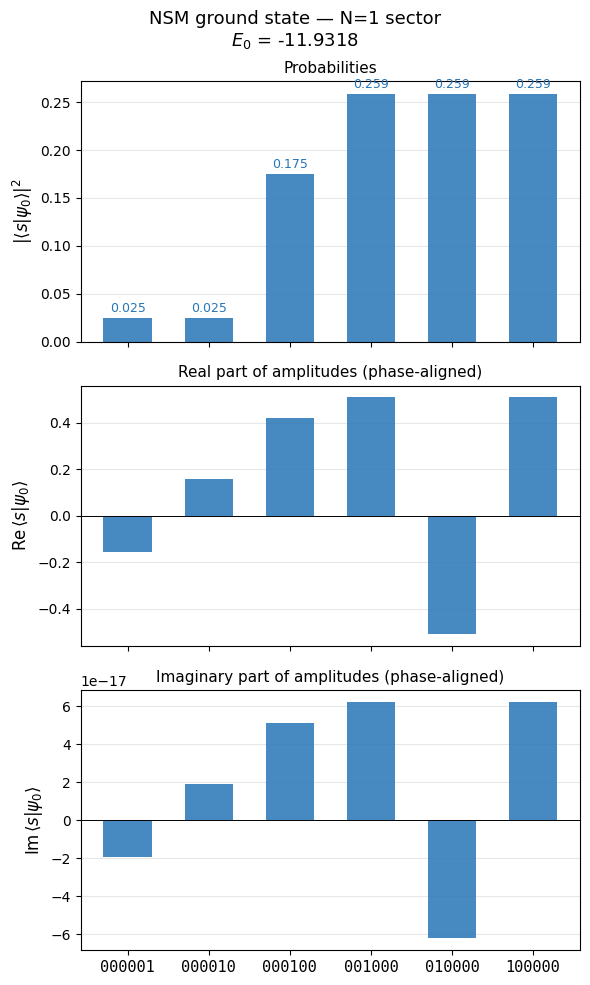

In [66]:
import matplotlib.pyplot as plt

# ── Amplitudes and probabilities of the NSM N=1 ground state ─────────────────

amps = ground_state_N1.full().flatten()  # complex amplitudes

# Phase-align: rotate so largest component is real+positive
idx_max = np.argmax(np.abs(amps))
amps_aligned = amps * np.exp(-1j * np.angle(amps[idx_max]))

probs = np.abs(amps_aligned) ** 2
re = amps_aligned.real
im = amps_aligned.imag

# Keep only N=1 sector bitstrings for plotting
basis_labels = ["".join(map(str, row)) for row in computational_basis(logical_qubits)]
n1_mask = np.array([sum(int(b) for b in lbl) == 1 for lbl in basis_labels])
labels_n1 = [l for l, m in zip(basis_labels, n1_mask) if m]

probs_n1 = probs[n1_mask]
re_n1 = re[n1_mask]
im_n1 = im[n1_mask]

# Print table
print(f"\n{'Bitstring':>12}  {'|amp|^2':>9}  {'Re(amp)':>9}  {'Im(amp)':>9}")
print("-" * 46)
for lbl, p, r, i_ in zip(labels_n1, probs_n1, re_n1, im_n1):
    print(f"{lbl:>12}  {p:>9.5f}  {r:>9.5f}  {i_:>9.5f}")

# ── Three-panel plot ──────────────────────────────────────────────────────────
CLR = "#2775b6"
x = np.arange(len(labels_n1))
width = 0.6

fig, axes = plt.subplots(3, 1, figsize=(max(6, len(labels_n1) * 0.9), 10), sharex=True)
fig.suptitle(
    f"NSM ground state — N=1 sector\n" f"$E_0$ = {ground_eigenvalue_N1:.4f}",
    fontsize=13,
)

# Panel 1: probabilities
ax = axes[0]
bars = ax.bar(x, probs_n1, width, color=CLR, alpha=0.85)
ax.set_ylabel(r"$|\langle s|\psi_0\rangle|^2$", fontsize=12)
ax.set_title("Probabilities", fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
for bar, v in zip(bars, probs_n1):
    if v > 0.005:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + 0.003,
            f"{v:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            color=CLR,
        )

# Panel 2: real parts
ax = axes[1]
bars = ax.bar(x, re_n1, width, color=CLR, alpha=0.85)
ax.axhline(0, color="k", linewidth=0.7)
ax.set_ylabel(r"$\mathrm{Re}\,\langle s|\psi_0\rangle$", fontsize=12)
ax.set_title("Real part of amplitudes (phase-aligned)", fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

# Panel 3: imaginary parts
ax = axes[2]
bars = ax.bar(x, im_n1, width, color=CLR, alpha=0.85)
ax.axhline(0, color="k", linewidth=0.7)
ax.set_ylabel(r"$\mathrm{Im}\,\langle s|\psi_0\rangle$", fontsize=12)
ax.set_title("Imaginary part of amplitudes (phase-aligned)", fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(labels_n1, fontfamily="monospace", fontsize=11)

plt.tight_layout()
plt.savefig("nsm_gs_wavefunction.pdf", bbox_inches="tight")
plt.show()

#### Getting the freaking effective Interaction

Optimal drive parameters: [-0.90513022  1.02535363 -0.96153052 -0.79417758 -1.10508836  1.13502171]
Optimized effective interaction matrix:
 [[ 0.00000000e+00  2.38278550e-01 -4.64010328e-01  1.81947765e-01
   9.31196813e-01  4.25607482e-01]
 [ 2.38278550e-01  0.00000000e+00  1.26008805e-01 -8.64690289e-02
  -5.12895154e-04  2.35762768e-01]
 [-4.64010328e-01  1.26008805e-01  0.00000000e+00  1.37155909e-01
  -3.27870147e-01 -7.07116593e-01]
 [ 1.81947765e-01 -8.64690289e-02  1.37155909e-01  0.00000000e+00
  -1.59923014e-01  1.83695410e-01]
 [ 9.31196813e-01 -5.12895154e-04 -3.27870147e-01 -1.59923014e-01
   0.00000000e+00  3.53399276e-01]
 [ 4.25607482e-01  2.35762768e-01 -7.07116593e-01  1.83695410e-01
   3.53399276e-01  0.00000000e+00]]


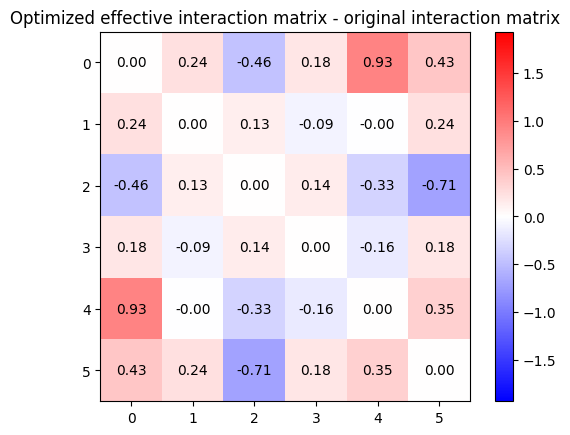

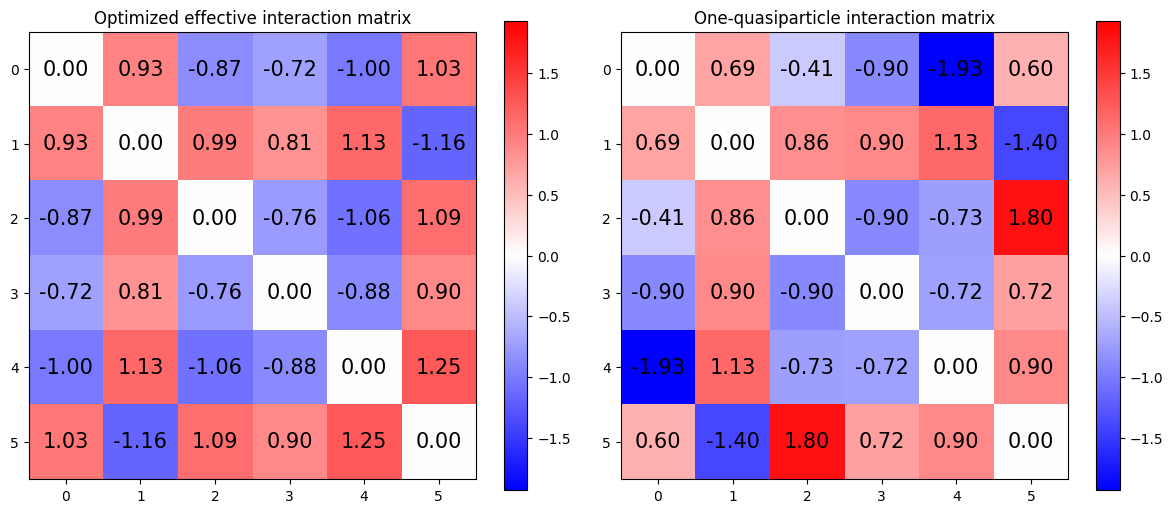

In [67]:
OptimalFieldBe6 = EffectiveInteractionOptimizer(
    nqubit=logical_qubits, n_restarts=100, scale=2.0, ftol=1e-15, gtol=1e-10
)

d_opt, result = OptimalFieldBe6.optimize_rank1(g_matrix)
print("Optimal drive parameters:", d_opt)
print(
    "Optimized effective interaction matrix:\n",
    OptimalFieldBe6.reconstructed(d_opt) - g_matrix,
)
plt.imshow(
    OptimalFieldBe6.reconstructed(d_opt) - g_matrix,
    cmap="bwr",
    vmin=-np.max(np.abs(g_matrix)),
    vmax=np.max(np.abs(g_matrix)),
)
for i in range(logical_qubits):
    for j in range(logical_qubits):
        plt.text(
            j,
            i,
            f"{OptimalFieldBe6.reconstructed(d_opt)[i,j]-g_matrix[i,j]:.2f}",
            ha="center",
            va="center",
            color="black",
        )
plt.colorbar()
plt.title("Optimized effective interaction matrix - original interaction matrix")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

vmax = np.max(np.abs(g_matrix))
matrices = [OptimalFieldBe6.reconstructed(d_opt), g_matrix]
titles = [
    "Optimized effective interaction matrix",
    "One-quasiparticle interaction matrix",
]

for ax, mat, title in zip(axes, matrices, titles):
    im = ax.imshow(mat, cmap="bwr", vmin=-vmax, vmax=vmax)
    for i in range(logical_qubits):
        for j in range(logical_qubits):
            ax.text(
                j,
                i,
                f"{mat[i,j]:.2f}",
                ha="center",
                va="center",
                color="black",
                fontsize=15,
            )
    plt.colorbar(im, ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

#### D-WAVE Embedding and effective Hamiltonians

In [68]:
import minorminer
import dwave_networkx as dnx
import networkx as nx

# K4: fully connected, 4 nodes = 6 edges
K4 = nx.complete_graph(6)
print("Problem edges:", list(K4.edges()))

# Hardware graph
hardware = dnx.pegasus_graph(16)

import minorminer

embedding = minorminer.find_embedding(K4, hardware)


# Manual verification
def check_embedding(embedding, problem_graph, hardware_graph):
    # Check 1: all chains connected in hardware
    for node, chain in embedding.items():
        subgraph = hardware_graph.subgraph(chain)
        if not nx.is_connected(subgraph):
            print(f"✗ q{node}: chain {chain} is NOT connected in hardware")
            return False

    # Check 2: every problem edge has a coupler between chains
    for u, v in problem_graph.edges():
        chain_u = set(embedding[u])
        chain_v = set(embedding[v])
        has_coupler = any(
            hardware_graph.has_edge(a, b) for a in chain_u for b in chain_v
        )
        if not has_coupler:
            print(
                f"✗ edge ({u},{v}): no coupler between chains {chain_u} and {chain_v}"
            )
            return False

    print("✓ Valid embedding")
    print(f"  Chain lengths: { {f'q{k}': len(v) for k,v in embedding.items()} }")
    return True


check_embedding(embedding, K4, hardware)

Problem edges: [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 2), (1, 3), (1, 4), (1, 5), (2, 3), (2, 4), (2, 5), (3, 4), (3, 5), (4, 5)]
✓ Valid embedding
  Chain lengths: {'q0': 2, 'q1': 1, 'q2': 1, 'q3': 1, 'q4': 1, 'q5': 2}


True

/tmp/ipykernel_3893/506417983.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


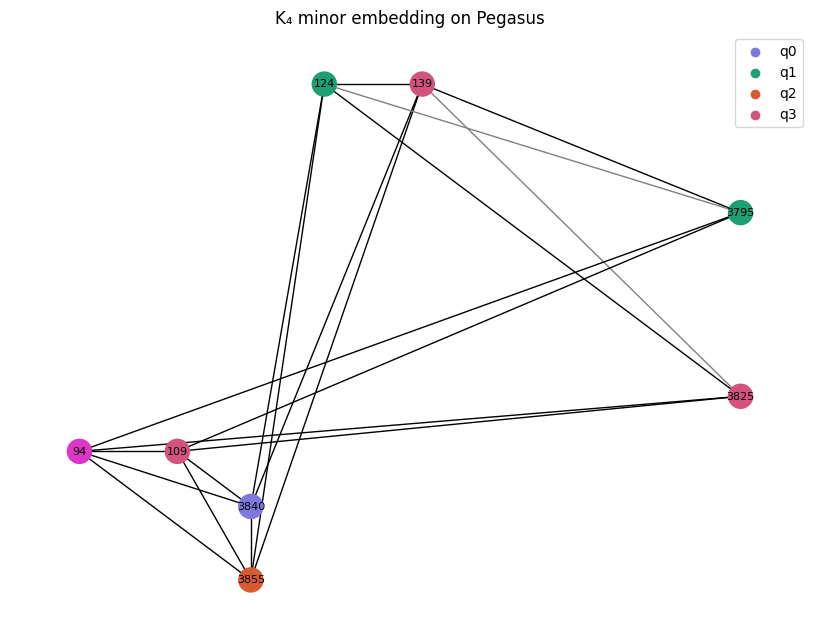

In [69]:
import matplotlib.pyplot as plt
import dwave_networkx as dnx
import minorminer
import networkx as nx

K4 = nx.complete_graph(6)
hardware = dnx.pegasus_graph(16)
embedding = minorminer.find_embedding(K4, hardware)

# Extract only the hardware nodes/edges used
used_nodes = [node for chain in embedding.values() for node in chain]
used_edges = []
for u, v in K4.edges():
    for a in embedding[u]:
        for b in embedding[v]:
            if hardware.has_edge(a, b):
                used_edges.append((a, b))

# Color by logical qubit
colors = [
    "#7F77DD",
    "#1D9E75",
    "#D85A30",
    "#D4537E",
    "#DD36C7",
    "#D4537E",
]  # purple, teal, coral, pink
node_colors = {}
for i, chain in embedding.items():
    for node in chain:
        node_colors[node] = colors[i]

subgraph = hardware.subgraph(used_nodes).copy()
for u, v in used_edges:
    if not subgraph.has_edge(u, v):
        subgraph.add_edge(u, v)

pos = dnx.pegasus_layout(subgraph)

plt.figure(figsize=(8, 6))
nx.draw(
    subgraph,
    pos,
    node_color=[node_colors[n] for n in subgraph.nodes()],
    edge_color=[
        "gray" if (u, v) not in used_edges and (v, u) not in used_edges else "black"
        for u, v in subgraph.edges()
    ],
    node_size=300,
    with_labels=True,
    font_size=8,
)
plt.title("K₄ minor embedding on Pegasus")
plt.legend(handles=[plt.scatter([], [], c=colors[i], label=f"q{i}") for i in range(4)])
plt.tight_layout()
plt.savefig("embedding.png", dpi=150)
plt.show()

In [70]:
print(used_nodes)
print(used_edges)

# build index map: physical qubit → local index 0..7
phys_to_idx = {phys: idx for idx, phys in enumerate(used_nodes)}

print("=== Physical → Local index ===")
for phys, idx in phys_to_idx.items():
    print(f"  {phys} → {idx}")

print("\n=== Chains (local indices) ===")
mapping = []
for logical, chain in embedding.items():
    local_chain = [phys_to_idx[p] for p in chain]
    mapping.append(local_chain)
    print(f"  q{logical} → {local_chain}")

print("\n=== Edges (local indices) ===")
local_edges = [(phys_to_idx[u], phys_to_idx[v]) for u, v in used_edges]
print(local_edges)

[3840, 3795, 124, 3855, 109, 94, 3825, 139]
[(3840, 124), (3840, 3855), (3840, 109), (3840, 94), (3840, 139), (124, 3855), (3795, 109), (3795, 94), (3795, 139), (124, 3825), (124, 139), (3855, 109), (3855, 94), (3855, 139), (109, 94), (109, 3825), (94, 3825)]
=== Physical → Local index ===
  3840 → 0
  3795 → 1
  124 → 2
  3855 → 3
  109 → 4
  94 → 5
  3825 → 6
  139 → 7

=== Chains (local indices) ===
  q0 → [0]
  q1 → [1, 2]
  q2 → [3]
  q3 → [4]
  q4 → [5]
  q5 → [6, 7]

=== Edges (local indices) ===
[(0, 2), (0, 3), (0, 4), (0, 5), (0, 7), (2, 3), (1, 4), (1, 5), (1, 7), (2, 6), (2, 7), (3, 4), (3, 5), (3, 7), (4, 5), (4, 6), (5, 6)]


Encoding

In [71]:
# chains dict: already comes from embedding + phys_to_idx
chains = {
    logical: [phys_to_idx[p] for p in chain] for logical, chain in embedding.items()
}

# intra_edges: pairs within the same chain that are connected in hardware
intra_edges = []
for logical, chain in chains.items():
    local_chain = [phys_to_idx[p] for p in embedding[logical]]
    for k in range(len(local_chain) - 1):
        intra_edges.append((local_chain[k], local_chain[k + 1]))

# inter_edges: all local_edges minus intra_edges
intra_set = set(map(frozenset, intra_edges))
inter_edges = [(u, v) for u, v in local_edges if frozenset((u, v)) not in intra_set]

print("Chains:", chains)
print("Intra edges:", intra_edges)
print("Inter edges:", inter_edges)
print("Representatives:", {l: chain[0] for l, chain in chains.items()})

Chains: {0: [0], 1: [1, 2], 2: [3], 3: [4], 4: [5], 5: [6, 7]}
Intra edges: [(1, 2), (6, 7)]
Inter edges: [(0, 2), (0, 3), (0, 4), (0, 5), (0, 7), (2, 3), (1, 4), (1, 5), (1, 7), (2, 6), (2, 7), (3, 4), (3, 5), (3, 7), (4, 5), (4, 6), (5, 6)]
Representatives: {0: 0, 1: 1, 2: 3, 3: 4, 4: 5, 5: 6}


In [72]:
# physical qubit -> logical qubit lookup
phys_to_logical = {}
for logical, chain in chains.items():
    for p in chain:
        phys_to_logical[p] = logical

In [73]:
# for each logical pair, find the physical coupler
logical_pair_to_physical_coupler = {}
for u, v in inter_edges:
    lu = phys_to_logical[u]
    lv = phys_to_logical[v]
    if lu == lv:
        continue
    pair = frozenset((lu, lv))
    if pair not in logical_pair_to_physical_coupler:
        logical_pair_to_physical_coupler[pair] = (u, v)

print("=== Logical pair → physical coupler ===")
for pair, (u, v) in logical_pair_to_physical_coupler.items():
    lu, lv = tuple(pair)
    print(f"  q{lu}-q{lv}: physical ({u},{v})")

=== Logical pair → physical coupler ===
  q0-q1: physical (0,2)
  q0-q2: physical (0,3)
  q0-q3: physical (0,4)
  q0-q4: physical (0,5)
  q0-q5: physical (0,7)
  q1-q2: physical (2,3)
  q1-q3: physical (1,4)
  q1-q4: physical (1,5)
  q1-q5: physical (1,7)
  q2-q3: physical (3,4)
  q2-q4: physical (3,5)
  q2-q5: physical (3,7)
  q3-q4: physical (4,5)
  q3-q5: physical (4,6)
  q4-q5: physical (5,6)


In [129]:
import qutip as qt
from ManyBodyQutip.qutip_class import SpinOperator, SpinHamiltonian
import numpy as np
from collections import defaultdict

gamma = 40
J_F = 200
n_physical = 8
N_tot = 1

identity = qt.tensor([qt.qeye(2)] * n_physical)

# build a lookup: logical qubit -> representative physical qubit
representatives = {logical: chain[0] for logical, chain in chains.items()}

# build a lookup: physical qubit -> logical qubit
phys_to_logical = {}
for logical, chain in chains.items():
    for p in chain:
        phys_to_logical[p] = logical

# recheck: with gamma=20, N_tot=1
# gamma*(1 - 2*N_tot) = 20*(1-2) = -20  ← this is correct
# but ZZ coupling 2*gamma = 40 per pair

# the problem is that for chains, BOTH physical qubits are being
# set in the one-hot state. The constraint must act on representatives ONLY.

# verify representatives
print("Representatives:", representatives)
# should be: {0:0, 1:1, 2:2, 3:4, 4:6, 5:7}
# q2 representative is 2 (not both 2 and 3)
# q3 representative is 4 (not both 4 and 5)

# rebuild hamiltonian_zz using ONLY representatives
hamiltonian_zz = 0.0
added_pairs = set()
for u, v in inter_edges:
    lu = phys_to_logical[u]
    lv = phys_to_logical[v]
    if lu == lv:
        continue
    pair = frozenset((lu, lv))
    if pair in added_pairs:
        continue
    added_pairs.add(pair)
    # use the actual hardware coupler (u,v), not the representatives
    print(f"  logical (q{lu},q{lv}): physical coupler ({u},{v})")
    hamiltonian_zz += SpinOperator(
        [("qz", u, "qz", v)], coupling=[2 * gamma], size=n_physical, verbose=0
    ).qutip_op
    print(
        f"Added NN coupling for logical pair (q{lu}, q{lv}) with physical coupler ({u},{v})"
    )
print(f"ZZ pairs added: {len(added_pairs)}")


# track which physical qubits carry ZZ for each logical qubit
logical_to_physical_in_zz = defaultdict(set)
for u, v in inter_edges:
    lu = phys_to_logical[u]
    lv = phys_to_logical[v]
    if lu == lv:
        continue
    pair = frozenset((lu, lv))
    if pair not in added_pairs:
        continue
    logical_to_physical_in_zz[lu].add(u)
    logical_to_physical_in_zz[lv].add(v)

# linear term: constraint + external field, split across physical qubits
hamiltonian_z = 0.0
for logical in range(6):
    phys_set = logical_to_physical_in_zz[logical]
    n_phys = len(phys_set)

    # constraint part: gamma*(1-2*N_tot) per logical qubit
    h_constraint = gamma * (1 - 2 * N_tot)

    h_total_logical = h_constraint

    # split equally across all physical qubits of this logical qubit
    for p in phys_set:
        print(p)
        hamiltonian_z += SpinOperator(
            [("qz", p)], coupling=[h_total_logical / n_phys], size=n_physical, verbose=0
        ).qutip_op

H_diagonal = 0.0
for logical, chain in chains.items():
    k = len(chain)
    eps = diagonal_elements[logical] / (gamma * k)
    for phys in chain:
        H_diagonal += SpinOperator(
            [("qz", phys)], coupling=[eps], size=n_physical
        ).qutip_op


identity = qt.tensor([qt.qeye(2)] * n_physical)
H_constraint = hamiltonian_zz + hamiltonian_z + gamma * (N_tot**2) * identity


H_ferro = 0.0
for a, b in intra_edges:
    H_ferro += SpinOperator(
        [("qz", a, "qz", b)], coupling=[-4 * J_F], size=n_physical, verbose=0
    ).qutip_op
    H_ferro += SpinOperator(
        [("qz", a)], coupling=[2 * J_F], size=n_physical, verbose=0
    ).qutip_op
    H_ferro += SpinOperator(
        [("qz", b)], coupling=[2 * J_F], size=n_physical, verbose=0
    ).qutip_op
    H_ferro += (-J_F) * identity


longitudinal_hamiltonian = H_constraint + H_ferro + H_diagonal

# check spectrum
evals = np.sort(np.real(longitudinal_hamiltonian.eigenenergies()))
print("Spectrum (first 8):", evals[:8])
print("Ground state degeneracy:", np.sum(np.isclose(evals, evals[0])))

Representatives: {0: 0, 1: 1, 2: 3, 3: 4, 4: 5, 5: 6}
  logical (q0,q1): physical coupler (0,2)
Added NN coupling for logical pair (q0, q1) with physical coupler (0,2)
  logical (q0,q2): physical coupler (0,3)
Added NN coupling for logical pair (q0, q2) with physical coupler (0,3)
  logical (q0,q3): physical coupler (0,4)
Added NN coupling for logical pair (q0, q3) with physical coupler (0,4)
  logical (q0,q4): physical coupler (0,5)
Added NN coupling for logical pair (q0, q4) with physical coupler (0,5)
  logical (q0,q5): physical coupler (0,7)
Added NN coupling for logical pair (q0, q5) with physical coupler (0,7)
  logical (q1,q2): physical coupler (2,3)
Added NN coupling for logical pair (q1, q2) with physical coupler (2,3)
  logical (q1,q3): physical coupler (1,4)
Added NN coupling for logical pair (q1, q3) with physical coupler (1,4)
  logical (q1,q4): physical coupler (1,5)
Added NN coupling for logical pair (q1, q4) with physical coupler (1,5)
  logical (q1,q5): physical couple

In [130]:
# get eigenvalues and eigenstates
evals, evecs = longitudinal_hamiltonian.eigenstates()

print("=== Lowest energy states ===")
for k in range(20):
    energy = evals[k]
    state = evecs[k]

    # get probabilities over computational basis
    probs = np.abs(state.full().flatten()) ** 2
    dominant_idx = np.argmax(probs)

    # convert to bitstring (8 qubits)
    bitstring = format(dominant_idx, f"0{n_physical}b")

    print(
        f"  E[{k}] = {energy:.4f} | bitstring: {bitstring} | prob: {probs[dominant_idx]:.4f}"
    )

=== Lowest energy states ===
  E[0] = -400.2329 | bitstring: 10000000 | prob: 1.0000
  E[1] = -400.2286 | bitstring: 00010000 | prob: 1.0000
  E[2] = -400.2215 | bitstring: 01100000 | prob: 1.0000
  E[3] = -400.2027 | bitstring: 00001000 | prob: 1.0000
  E[4] = -399.9194 | bitstring: 00000100 | prob: 1.0000
  E[5] = -399.9194 | bitstring: 00000011 | prob: 1.0000
  E[6] = -360.4615 | bitstring: 10010000 | prob: 1.0000
  E[7] = -360.4544 | bitstring: 11100000 | prob: 1.0000
  E[8] = -360.4502 | bitstring: 01110000 | prob: 1.0000
  E[9] = -360.4356 | bitstring: 10001000 | prob: 1.0000
  E[10] = -360.4313 | bitstring: 00011000 | prob: 1.0000
  E[11] = -360.4242 | bitstring: 01101000 | prob: 1.0000
  E[12] = -360.1522 | bitstring: 10000011 | prob: 1.0000
  E[13] = -360.1522 | bitstring: 10000100 | prob: 1.0000
  E[14] = -360.1480 | bitstring: 00010011 | prob: 1.0000
  E[15] = -360.1480 | bitstring: 00010100 | prob: 1.0000
  E[16] = -360.1409 | bitstring: 01100011 | prob: 1.0000
  E[17] = -3

In [131]:
print("\n=== Chain qubit used for each logical pair ===")
added_pairs2 = set()
for u, v in inter_edges:
    lu = phys_to_logical[u]
    lv = phys_to_logical[v]
    if lu == lv:
        continue
    pair = frozenset((lu, lv))
    if pair in added_pairs2:
        continue
    added_pairs2.add(pair)
    ru, rv = representatives[lu], representatives[lv]
    flag = ""
    if u != ru or v != rv:
        flag = "  ← NON-REPRESENTATIVE"
    print(f"  logical (q{lu},q{lv}): physical ({u},{v}) | reps ({ru},{rv}){flag}")


=== Chain qubit used for each logical pair ===
  logical (q0,q1): physical (0,2) | reps (0,1)  ← NON-REPRESENTATIVE
  logical (q0,q2): physical (0,3) | reps (0,3)
  logical (q0,q3): physical (0,4) | reps (0,4)
  logical (q0,q4): physical (0,5) | reps (0,5)
  logical (q0,q5): physical (0,7) | reps (0,6)  ← NON-REPRESENTATIVE
  logical (q1,q2): physical (2,3) | reps (1,3)  ← NON-REPRESENTATIVE
  logical (q1,q3): physical (1,4) | reps (1,4)
  logical (q1,q4): physical (1,5) | reps (1,5)
  logical (q1,q5): physical (1,7) | reps (1,6)  ← NON-REPRESENTATIVE
  logical (q2,q3): physical (3,4) | reps (3,4)
  logical (q2,q4): physical (3,5) | reps (3,5)
  logical (q2,q5): physical (3,7) | reps (3,6)  ← NON-REPRESENTATIVE
  logical (q3,q4): physical (4,5) | reps (4,5)
  logical (q3,q5): physical (4,6) | reps (4,6)
  logical (q4,q5): physical (5,6) | reps (5,6)


In [132]:
# check each term independently
print("=== H_constraint diagonal ===")
diag_constraint = np.real(longitudinal_hamiltonian.full().diagonal())
idx_sorted = np.argsort(diag_constraint)
for k in idx_sorted[:6]:
    bitstring = format(k, f"0{n_physical}b")[::-1]
    n_particles = sum(int(b) for b in bitstring)
    print(f"  {bitstring} | N={n_particles} | E={diag_constraint[k]:.4f}")

print("\n=== H_ferro diagonal ===")
diag_ferro = np.real(H_ferro.full().diagonal())
idx_sorted = np.argsort(diag_ferro)
for k in idx_sorted[:6]:
    bitstring = format(k, f"0{n_physical}b")[::-1]
    print(f"  {bitstring} | E={diag_ferro[k]:.4f}")

print("\n=== H_total diagonal ===")
diag_total = np.real(longitudinal_hamiltonian.full().diagonal())
idx_sorted = np.argsort(diag_total)
for k in idx_sorted[:6]:
    bitstring = format(k, f"0{n_physical}b")[::-1]
    n_particles = sum(int(b) for b in bitstring)
    print(f"  {bitstring} | N={n_particles} | E={diag_total[k]:.4f}")

# also print current parameter values
print(f"\ngamma={gamma}, J_F={J_F}, N_tot={N_tot}")
print(f"chains: {chains}")
print(f"intra_edges: {intra_edges}")
print(f"representatives: {representatives}")

=== H_constraint diagonal ===
  00000001 | N=1 | E=-400.2329
  00001000 | N=1 | E=-400.2286
  00000110 | N=2 | E=-400.2215
  00010000 | N=1 | E=-400.2027
  11000000 | N=2 | E=-399.9194
  00100000 | N=1 | E=-399.9194

=== H_ferro diagonal ===
  00000000 | E=-400.0000
  11000000 | E=-400.0000
  11100000 | E=-400.0000
  00100000 | E=-400.0000
  00110000 | E=-400.0000
  11110000 | E=-400.0000

=== H_total diagonal ===
  00000001 | N=1 | E=-400.2329
  00001000 | N=1 | E=-400.2286
  00000110 | N=2 | E=-400.2215
  00010000 | N=1 | E=-400.2027
  11000000 | N=2 | E=-399.9194
  00100000 | N=1 | E=-399.9194

gamma=40, J_F=200, N_tot=1
chains: {0: [0], 1: [1, 2], 2: [3], 3: [4], 4: [5], 5: [6, 7]}
intra_edges: [(1, 2), (6, 7)]
representatives: {0: 0, 1: 1, 2: 3, 3: 4, 4: 5, 5: 6}


In [133]:
print("=== Constraint energy for one-hot states ===")
for logical in range(6):
    # construct one-hot: only representative of this logical qubit is 1
    idx = 0
    for l, chain in chains.items():
        if l == logical:
            for p in chain:
                idx += 1 << p  # set bit p
    bitstring = format(idx, f"0{n_physical}b")[::-1]
    e = diag_constraint[idx]
    n_particles = sum(int(b) for b in bitstring)
    print(f"  q{logical} occupied: {bitstring} | N={n_particles} | E={e:.4f}")

print("\n=== Constraint energy for vacuum ===")
print(f"  E(vacuum) = {diag_constraint[0]:.4f}")

print("\n=== Constraint energy for two-particle states ===")
for i in range(6):
    for j in range(i + 1, 6):
        idx = 0
        for p in chains[i]:
            idx += 1 << p
        for p in chains[j]:
            idx += 1 << p
        e = diag_constraint[idx]
        print(f"  q{i},q{j}: E={e:.4f}")

=== Constraint energy for one-hot states ===
  q0 occupied: 10000000 | N=1 | E=20.0403
  q1 occupied: 01100000 | N=2 | E=60.1209
  q2 occupied: 00010000 | N=1 | E=-400.2027
  q3 occupied: 00001000 | N=1 | E=-400.2286
  q4 occupied: 00000100 | N=1 | E=19.8892
  q5 occupied: 00000011 | N=2 | E=-20.3436

=== Constraint energy for vacuum ===
  E(vacuum) = -360.0000

=== Constraint energy for two-particle states ===
  q0,q1: E=-359.8387
  q0,q2: E=-20.1624
  q0,q3: E=59.8117
  q0,q4: E=399.9295
  q0,q5: E=519.6967
  q1,q2: E=179.9183
  q1,q3: E=99.8923
  q1,q4: E=440.0102
  q1,q5: E=559.7773
  q2,q3: E=-360.4313
  q2,q4: E=-20.3134
  q2,q5: E=99.4537
  q3,q4: E=59.6606
  q3,q5: E=19.4277
  q4,q5: E=-360.4544


##### Adding the transverse field

In [139]:
d_phys = np.zeros(n_physical)
for logical, chain in chains.items():
    if len(chain) == 1:
        d_phys[chain[0]] = d_opt[logical] / np.sqrt(2)
    else:
        d_logical = d_opt[logical] / np.sqrt(2)
        magnitude = np.sqrt(np.abs(d_logical) * J_F)
        d_phys[chain[0]] = +magnitude
        d_phys[chain[1]] = -1 * np.sign(d_logical) * magnitude

# transverse field on physical qubits
transverse_hamiltonian = 0.0
for phys_idx in range(n_physical):
    transverse_hamiltonian += SpinOperator(
        [("x", phys_idx)], coupling=[d_phys[phys_idx]], size=n_physical, verbose=0
    ).qutip_op

Generalized formula

In [135]:
d_phys = np.zeros(n_physical)
for logical, chain in chains.items():
    k = len(chain)
    d_logical = d_opt[logical] / np.sqrt(2)
    magnitude = (np.abs(d_logical) ** (1 / k)) * (J_F ** ((k - 1) / k))
    for i, phys in enumerate(chain):
        if i == 0:
            d_phys[phys] = +magnitude
        else:
            d_phys[phys] = -np.sign(d_logical) * magnitude  # sign on one qubit only
# transverse field on physical qubits
transverse_hamiltonian = 0.0
for phys_idx in range(n_physical):
    transverse_hamiltonian += SpinOperator(
        [("x", phys_idx)], coupling=[d_phys[phys_idx]], size=n_physical, verbose=0
    ).qutip_op

In [140]:
# full hamiltonian with transverse field
H_total = H_constraint + H_ferro + transverse_hamiltonian + H_diagonal

# diagonalize
evals, evecs = H_total.eigenstates()
gs_emb = evecs[0].full().flatten()
print("=== Ground state analysis ===")
print(f"Ground state energy: {np.real(evals[0]):.6f}")
print(f"First excited energy: {np.real(evals[1]):.6f}")
print(f"Gap: {np.real(evals[1] - evals[0]):.6f}")

print("\n=== Ground state bitstring decomposition ===")
gs = evecs[0]
probs = np.abs(gs.full().flatten()) ** 2

# sort by probability
sorted_idx = np.argsort(probs)[::-1]

print(f"{'bitstring':>12}  {'prob':>8}  {'logical meaning'}")
print("-" * 50)
for idx in sorted_idx[:10]:  # top 10 components
    if probs[idx] < 1e-6:
        break
    bitstring = format(idx, f"0{n_physical}b")  # reverse for q0=LSB

    # identify which logical qubit is occupied
    occupied_physical = [i for i, b in enumerate(bitstring) if b == "1"]
    occupied_logical = []
    for phys in occupied_physical:
        for logical, chain in chains.items():
            if phys in chain:
                occupied_logical.append(f"q{logical}")

    print(f"  {bitstring}  {probs[idx]:>8.4f}  {occupied_logical}")

=== Ground state analysis ===
Ground state energy: -401.837332
First excited energy: -401.746801
Gap: 0.090531

=== Ground state bitstring decomposition ===
   bitstring      prob  logical meaning
--------------------------------------------------
  10000000    0.2952  ['q0']
  00010000    0.2863  ['q2']
  01100000    0.2346  ['q1', 'q1']
  00001000    0.1362  ['q3']
  00000011    0.0201  ['q5', 'q5']
  00000100    0.0198  ['q4']
  00000000    0.0013  []
  10000010    0.0003  ['q0', 'q5']
  00010010    0.0003  ['q2', 'q5']
  10010000    0.0003  ['q0', 'q2']


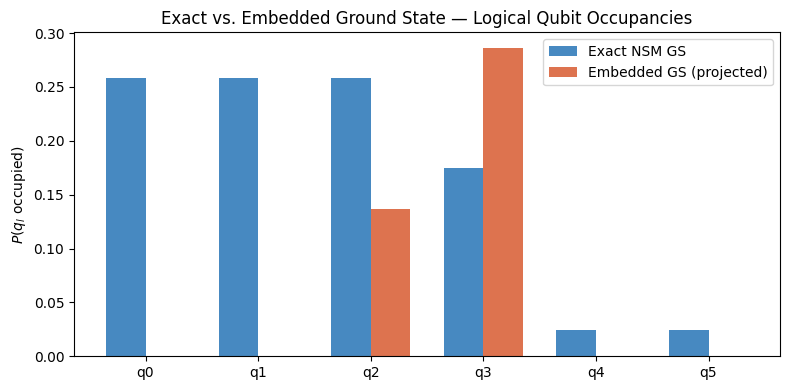


 Logical    Exact prob   Embedded prob     Ratio
------------------------------------------------
  q0          0.25870         0.00003    0.0001
  q1          0.25870         0.00002    0.0001
  q2          0.25870         0.13623    0.5266
  q3          0.17485         0.28631    1.6375
  q4          0.02453         0.00022    0.0092
  q5          0.02453         0.00032    0.0129


In [141]:
# === Comparison: embedded GS vs. exact NSM GS ===

# 1. logical qubit ordering: q0..q5 from the exact wavefunction plot
# Exact GS: probabilities are for bitstrings 000001, 000010, 000100, 001000, 010000, 100000
# i.e. qubit 5, 4, 3, 2, 1, 0 occupied respectively (QuTiP: q0=MSB)
exact_probs = {}  # logical qubit index -> probability
for logical in range(logical_qubits):
    # one-hot state: only logical qubit `logical` occupied
    # in QuTiP ordering, qubit 0 is MSB, so qubit `logical` occupies bit (logical_qubits-1-logical) from right
    idx_exact = 1 << (logical_qubits - 1 - logical)  # wrong! see below
    # Actually: basis label "100000" means q0=1, which in QuTiP is index 2^(n-1)
    # "000001" means q5=1, which is index 2^0 = 1
    # So logical qubit l corresponds to index 2^(logical_qubits - 1 - l)
    gs_full = ground_state_N1.full().flatten()
    exact_probs[logical] = np.abs(gs_full[1 << (logical_qubits - 1 - logical)]) ** 2

# 2. Embedded GS: for each logical qubit, sum probability over all chain configs
embedded_probs = {}
gs_emb_full = gs.full().flatten()  # gs from the embedded diagonalization

for logical in range(logical_qubits):
    chain = chains[logical]
    # valid physical states: all qubits in chain are 1, all others 0
    # (ferromagnetic constraint forces all chain qubits to agree)
    total_prob = 0.0
    for phys_state in range(2**n_physical):
        bits = [(phys_state >> p) & 1 for p in range(n_physical)]
        # check: all chain qubits are 1
        if all(bits[p] == 1 for p in chain):
            # check: no other chain qubits are 1 (strict one-hot on logical level)
            other_occupied = [
                p for p in range(n_physical) if bits[p] == 1 and p not in chain
            ]
            if len(other_occupied) == 0:
                total_prob += np.abs(gs_emb_full[phys_state]) ** 2
    embedded_probs[logical] = total_prob

# 3. Plot comparison
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(logical_qubits)
w = 0.35
ax.bar(
    x - w / 2,
    [exact_probs[l] for l in range(logical_qubits)],
    w,
    label="Exact NSM GS",
    color="#2775b6",
    alpha=0.85,
)
ax.bar(
    x + w / 2,
    [embedded_probs[l] for l in range(logical_qubits)],
    w,
    label="Embedded GS (projected)",
    color="#d85a30",
    alpha=0.85,
)
ax.set_xticks(x)
ax.set_xticklabels([f"q{l}" for l in range(logical_qubits)])
ax.set_ylabel(r"$P(q_l \text{ occupied})$")
ax.set_title("Exact vs. Embedded Ground State — Logical Qubit Occupancies")
ax.legend()
plt.tight_layout()
plt.savefig("comparison_exact_vs_embedded.pdf")
plt.show()

print(f"\n{'Logical':>8}  {'Exact prob':>12}  {'Embedded prob':>14}  {'Ratio':>8}")
print("-" * 48)
for l in range(logical_qubits):
    r = embedded_probs[l] / exact_probs[l] if exact_probs[l] > 1e-10 else float("nan")
    print(f"  q{l}     {exact_probs[l]:>12.5f}  {embedded_probs[l]:>14.5f}  {r:>8.4f}")

 Logical   Re(exact)     Re(emb)   Im(exact)     Im(emb)   |exact|^2     |emb|^2
---------------------------------------------------------------------------
  q0     0.50862     0.54330     0.00000     0.00000     0.25870     0.29517
  q1    -0.50862    -0.48440    -0.00000    -0.00000     0.25870     0.23464
  q2     0.50862     0.53508     0.00000     0.00000     0.25870     0.28631
  q3     0.41815     0.36909     0.00000     0.00000     0.17485     0.13623
  q4     0.15662     0.14084     0.00000     0.00000     0.02453     0.01984
  q5    -0.15662    -0.14176    -0.00000    -0.00000     0.02453     0.02010

Norm of projected embedded wavefunction: 0.99228
(< 1 means weight lost to domain-wall / multi-particle states)


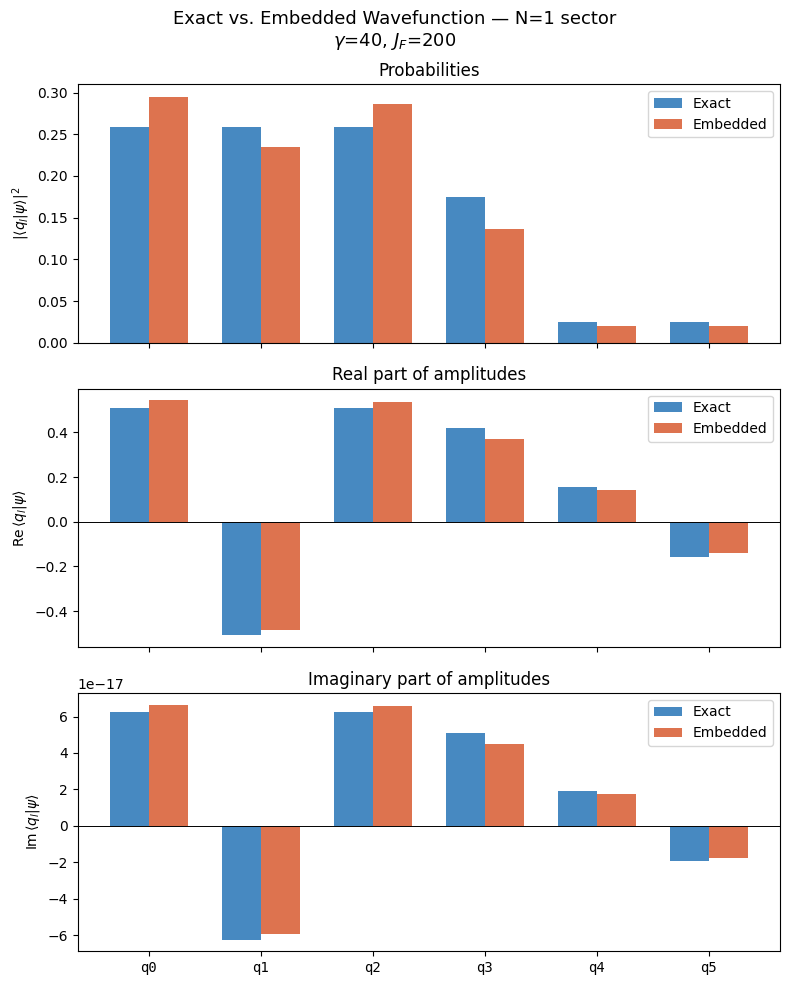

In [142]:
# === Full wavefunction comparison: amplitudes ===

# --- Exact amplitudes (phase-aligned to largest component) ---
gs_exact = ground_state_N1.full().flatten()
exact_amps = np.array(
    [gs_exact[qutip_idx([l], logical_qubits)] for l in range(logical_qubits)]
)

# phase-align exact to largest component
idx_max = np.argmax(np.abs(exact_amps))
exact_amps = exact_amps * np.exp(-1j * np.angle(exact_amps[idx_max]))

# --- Embedded amplitudes (projected onto logical one-hot states) ---
emb_amps = np.array(
    [gs_emb[qutip_idx(chains[l], n_physical)] for l in range(logical_qubits)]
)

# phase-align embedded to same reference (q_idx_max)
emb_amps = emb_amps * np.exp(-1j * np.angle(emb_amps[idx_max]))

# --- Print table ---
print(
    f"{'Logical':>8}  {'Re(exact)':>10}  {'Re(emb)':>10}  {'Im(exact)':>10}  {'Im(emb)':>10}  {'|exact|^2':>10}  {'|emb|^2':>10}"
)
print("-" * 75)
for l in range(logical_qubits):
    print(
        f"  q{l}  "
        f"{exact_amps[l].real:>10.5f}  {emb_amps[l].real:>10.5f}  "
        f"{exact_amps[l].imag:>10.5f}  {emb_amps[l].imag:>10.5f}  "
        f"{np.abs(exact_amps[l])**2:>10.5f}  {np.abs(emb_amps[l])**2:>10.5f}"
    )

# overall norm of projected embedded state
print(f"\nNorm of projected embedded wavefunction: {np.sum(np.abs(emb_amps)**2):.5f}")
print("(< 1 means weight lost to domain-wall / multi-particle states)")

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
x = np.arange(logical_qubits)
w = 0.35
labels = [f"q{l}" for l in range(logical_qubits)]
CLR_E = "#2775b6"
CLR_M = "#d85a30"

axes[0].bar(
    x - w / 2, np.abs(exact_amps) ** 2, w, label="Exact", color=CLR_E, alpha=0.85
)
axes[0].bar(
    x + w / 2, np.abs(emb_amps) ** 2, w, label="Embedded", color=CLR_M, alpha=0.85
)
axes[0].set_ylabel(r"$|\langle q_l|\psi\rangle|^2$")
axes[0].set_title("Probabilities")
axes[0].legend()

axes[1].bar(x - w / 2, exact_amps.real, w, color=CLR_E, alpha=0.85, label="Exact")
axes[1].bar(x + w / 2, emb_amps.real, w, color=CLR_M, alpha=0.85, label="Embedded")
axes[1].axhline(0, color="k", linewidth=0.7)
axes[1].set_ylabel(r"$\mathrm{Re}\,\langle q_l|\psi\rangle$")
axes[1].set_title("Real part of amplitudes")
axes[1].legend()

axes[2].bar(x - w / 2, exact_amps.imag, w, color=CLR_E, alpha=0.85, label="Exact")
axes[2].bar(x + w / 2, emb_amps.imag, w, color=CLR_M, alpha=0.85, label="Embedded")
axes[2].axhline(0, color="k", linewidth=0.7)
axes[2].set_ylabel(r"$\mathrm{Im}\,\langle q_l|\psi\rangle$")
axes[2].set_title("Imaginary part of amplitudes")
axes[2].legend()

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(labels, fontfamily="monospace")
fig.suptitle(
    f"Exact vs. Embedded Wavefunction — N=1 sector\n" f"$\\gamma$={gamma}, $J_F$={J_F}",
    fontsize=13,
)
plt.tight_layout()
plt.savefig("wavefunction_comparison.pdf", bbox_inches="tight")
plt.show()